# Interactive Dataset Inspection Notebook

This notebook allows you to conveniently and interactively inspect samples from your preprocessed Hugging Face dataset. 

- Use the slider to select a sample index.
- View both the original and decoded (de-tokenized) text for each sample.
- Useful for verifying tokenization, data integrity, and exploring your dataset.

**Requirements:**
- The dataset and tokenizer must be saved in the same directory (e.g., `data/processed/tokenized_dataset`).
- The notebook uses `ipywidgets` for interactivity.


In [3]:
# Import required libraries
import os
from datasets import load_from_disk
from transformers import AutoTokenizer
import ipywidgets as widgets
from IPython.display import display, Markdown, HTML

In [4]:
# Set dataset path and load dataset/tokenizer
DATASET_PATH = "/home/pwiesenbach/BertGCN/data/processed/tokenized_dataset"

# Load dataset
print(f"Loading dataset from: {DATASET_PATH}")
dataset = load_from_disk(DATASET_PATH)
print(f"Loaded dataset with {len(dataset)} samples.")

# Load tokenizer
print(f"Loading tokenizer from: {DATASET_PATH}")
tokenizer = AutoTokenizer.from_pretrained(DATASET_PATH)
print("Tokenizer loaded.")

Loading dataset from: /home/pwiesenbach/BertGCN/data/processed/tokenized_dataset
Loaded dataset with 2699 samples.
Loading tokenizer from: /home/pwiesenbach/BertGCN/data/processed/tokenized_dataset
Tokenizer loaded.


In [5]:
# Interactive inspection function and widget

def inspect_sample(index):
    sample = dataset[index]
    original_text = sample.get('text', 'N/A')
    input_ids = sample['input_ids']
    decoded_text = tokenizer.decode(input_ids, skip_special_tokens=True)
    
    display(Markdown(f"### Sample Index: {index}"))
    display(Markdown("**Original Text:**"))
    display(HTML(f"<div style='white-space: pre-wrap; border:1px solid #ccc; padding:8px; background:#f9f9f9'>{original_text}</div>"))
    display(Markdown("**Decoded Text:**"))
    display(HTML(f"<div style='white-space: pre-wrap; border:1px solid #e0e0e0; padding:8px; background:#f4f4f4'>{decoded_text}</div>"))
    display(Markdown(f"*Original length: {len(original_text)} | Decoded length: {len(decoded_text)}*"))

slider = widgets.IntSlider(
    min=0,
    max=len(dataset)-1,
    step=1,
    value=0,
    description='Sample Index:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

out = widgets.interactive_output(inspect_sample, {'index': slider})
display(widgets.VBox([slider, out]))

# Label Distribution

The next cell computes and visualizes the distribution of labels in the loaded `dataset`.
It will:
- Derive label names if available (ClassLabel)
- Count label frequencies
- Show a bar chart and a table (count & percentage)

Useful for quickly detecting class imbalance.

Loaded LabelEncoder from /home/pwiesenbach/BertGCN/data/processed/label_encoder.joblib
| ID | Original Label | Count | Percent |
|---:|:--------------|------:|--------:|
| 0 | Blutdrucksenker_Blutdruck | 916 | 33.94% |
| 1 | Blutdrucksenker_Herzschw | 176 | 6.52% |
| 2 | Blutdrucksenker_Hypercholesterin | 1 | 0.04% |
| 3 | Blutdrucksenker_beides | 769 | 28.49% |
| 4 | Blutdrucksenker_unklar | 93 | 3.45% |
| 5 | Cholesterinsenker_Hypercholesterin | 35 | 1.30% |
| 6 | Cholesterinsenker_KHK | 152 | 5.63% |
| 7 | Cholesterinsenker_beides | 314 | 11.63% |
| 8 | Cholesterinsenker_unklar | 32 | 1.19% |
| 9 | DM_Insulin und Tabletten | 74 | 2.74% |
| 10 | DM_nur Insulin | 45 | 1.67% |
| 11 | DM_nur Tabletten | 92 | 3.41% |


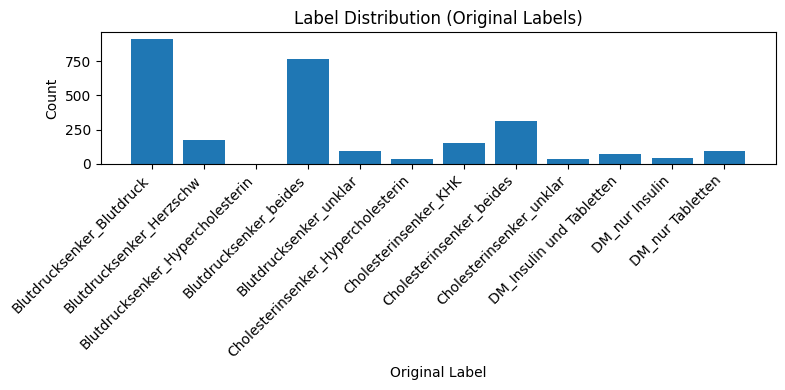

In [7]:
# Compute and display label distribution (with original label decoding)
import collections
from IPython.display import Markdown, display
from pathlib import Path
import numpy as np

# Load LabelEncoder (original labels) if available
label_encoder_path = Path(DATASET_PATH).parent / 'label_encoder.joblib'
label_encoder = None
if label_encoder_path.exists():
    try:
        import joblib
        label_encoder = joblib.load(label_encoder_path)
        print(f"Loaded LabelEncoder from {label_encoder_path}")
    except Exception as e:
        print(f"Could not load LabelEncoder: {e}")
else:
    print(f"LabelEncoder not found at {label_encoder_path}; proceeding without it.")

# Determine label column name
label_column_name = 'labels' if 'labels' in dataset.column_names else 'label'
raw_labels = dataset[label_column_name]

counter = collections.Counter(raw_labels)

rows = []
for lab_id, count in sorted(counter.items(), key=lambda x: x[0]):
    if label_encoder is not None:
        try:
            original = label_encoder.inverse_transform([lab_id])[0]
        except Exception:
            original = str(lab_id)
    else:
        original = str(lab_id)
    pct = count / len(raw_labels) * 100
    rows.append((lab_id, original, count, pct))

# Display table (includes decoded/original label)
header = '| ID | Original Label | Count | Percent |\n|---:|:--------------|------:|--------:|'
lines = [header] + [f"| {lid} | {orig} | {cnt} | {pct:.2f}% |" for (lid, orig, cnt, pct) in rows]
print('\n'.join(lines))

# Bar plot
try:
    import matplotlib.pyplot as plt
    ids = [r[0] for r in rows]
    counts = [r[2] for r in rows]
    labels_for_plot = [r[1] for r in rows]
    plt.figure(figsize=(8,4))
    plt.bar(range(len(ids)), counts, tick_label=labels_for_plot)
    plt.title('Label Distribution (Original Labels)')
    plt.xlabel('Original Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
except Exception as e:
    display(Markdown(f"Plotting skipped: {e}"))